# Audit a Dataset for Bias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

C:\Users\D\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.1)
  from scipy.stats import gaussian_kde


#### Load the dataset

In [2]:
try:
    df = pd.read_csv('compas-scores-two-years.csv')  
except FileNotFoundError:
    print("File not found. Please check the file path.")
    exit()

#### data exploration

In [3]:
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn dtypes:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())

Dataset shape: (7214, 53)

First 5 rows:
   id                name   first         last compas_screening_date   sex  \
0   1    miguel hernandez  miguel    hernandez            2013-08-14  Male   
1   3         kevon dixon   kevon        dixon            2013-01-27  Male   
2   4            ed philo      ed        philo            2013-04-14  Male   
3   5         marcu brown   marcu        brown            2013-01-13  Male   
4   6  bouthy pierrelouis  bouthy  pierrelouis            2013-03-26  Male   

          dob  age          age_cat              race  ...  v_decile_score  \
0  1947-04-18   69  Greater than 45             Other  ...               1   
1  1982-01-22   34          25 - 45  African-American  ...               1   
2  1991-05-14   24     Less than 25  African-American  ...               3   
3  1993-01-21   23     Less than 25  African-American  ...               6   
4  1973-01-22   43          25 - 45             Other  ...               1   

   v_score_text  v_sc

#### Data cleaning

In [4]:
# Convert dates to datetime
date_cols = ['compas_screening_date', 'c_jail_in', 'c_jail_out', 'c_offense_date', 
             'c_arrest_date', 'r_offense_date', 'r_jail_in', 'r_jail_out',
             'vr_offense_date', 'screening_date', 'v_screening_date',
             'in_custody', 'out_custody']

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

In [5]:
# Convert score columns to numeric
score_cols = ['decile_score', 'v_decile_score', 'priors_count']
for col in score_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [6]:
# statistics
print("\nDescriptive statistics:")
print(df[['age', 'decile_score', 'priors_count', 'two_year_recid']].describe())


Descriptive statistics:
               age  decile_score  priors_count  two_year_recid
count  7214.000000   7214.000000   7214.000000     7214.000000
mean     34.817993      4.509565      3.472415        0.450652
std      11.888922      2.856396      4.882538        0.497593
min      18.000000      1.000000      0.000000        0.000000
25%      25.000000      2.000000      0.000000        0.000000
50%      31.000000      4.000000      2.000000        0.000000
75%      42.000000      7.000000      5.000000        1.000000
max      96.000000     10.000000     38.000000        1.000000


#### Recidivism analysis

In [7]:
recidivism_rate = df['two_year_recid'].mean()
print(f"\nOverall recidivism rate: {recidivism_rate:.2%}")


Overall recidivism rate: 45.07%


### Visualizations

In [8]:
plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

#### 1. Recidivism by Race

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Other'),
  Text(1, 0, 'African-American'),
  Text(2, 0, 'Caucasian'),
  Text(3, 0, 'Hispanic'),
  Text(4, 0, 'Native American'),
  Text(5, 0, 'Asian')])

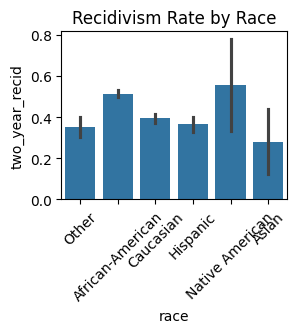

In [9]:
plt.subplot(2, 2, 1)
sns.barplot(x='race', y='two_year_recid', data=df, estimator=np.mean)
plt.title('Recidivism Rate by Race')
plt.xticks(rotation=45)

#### 2. Decile Score Distribution

Text(0.5, 1.0, 'Distribution of Decile Scores')

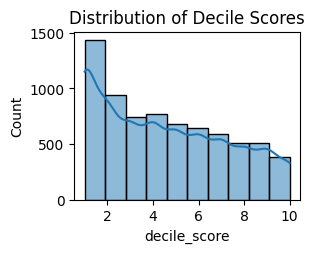

In [10]:
plt.subplot(2, 2, 2)
sns.histplot(data=df, x='decile_score', bins=10, kde=True)
plt.title('Distribution of Decile Scores')

#### 3. Prior Counts vs Recidivism

Text(0.5, 1.0, 'Prior Counts by Recidivism Status')

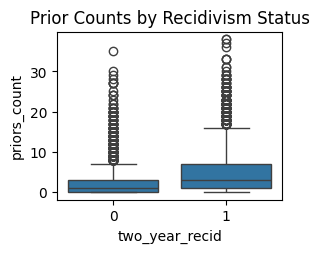

In [11]:
plt.subplot(2, 2, 3)
sns.boxplot(x='two_year_recid', y='priors_count', data=df)
plt.title('Prior Counts by Recidivism Status')

#### 4. Age Distribution

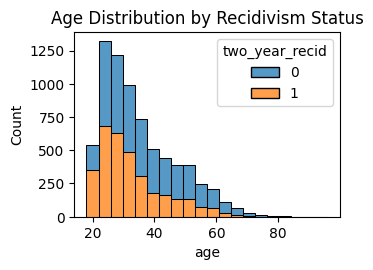

In [12]:
plt.subplot(2, 2, 4)
sns.histplot(data=df, x='age', bins=20, hue='two_year_recid', multiple='stack')
plt.title('Age Distribution by Recidivism Status')

plt.tight_layout()
plt.show()

#### Advanced Analysis: Racial bias in scores

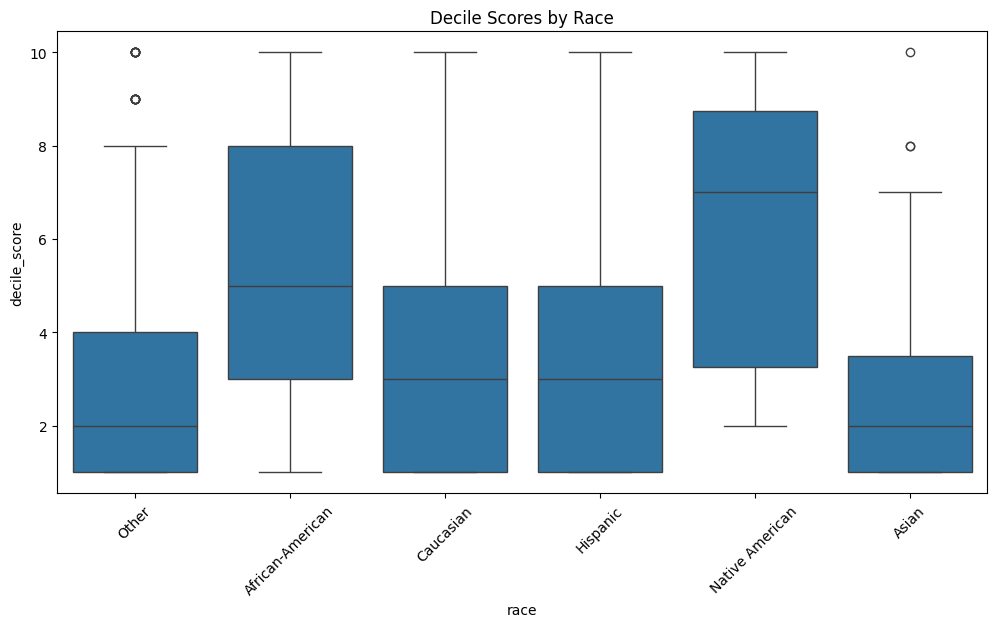

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='race', y='decile_score', data=df)
plt.title('Decile Scores by Race')
plt.xticks(rotation=45)
plt.show()

#### Correlation between priors and scores

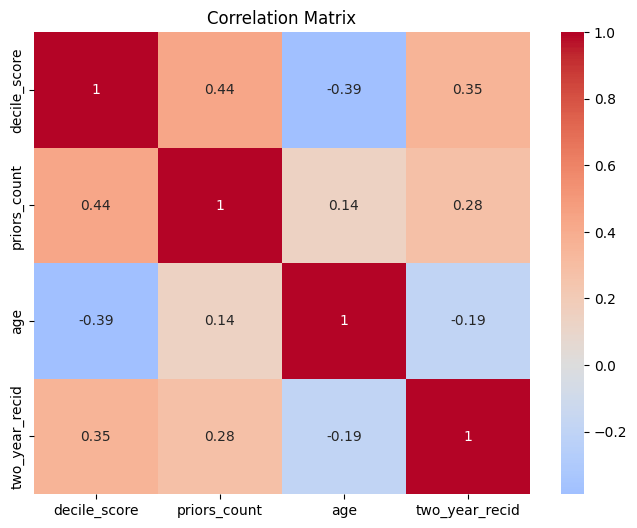

In [14]:
corr = df[['decile_score', 'priors_count', 'age', 'two_year_recid']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [15]:
# Save cleaned data
df.to_csv('compas_cleaned.csv', index=False)
print("\nAnalysis complete. Cleaned data saved to compas_cleaned.csv")


Analysis complete. Cleaned data saved to compas_cleaned.csv
